In [12]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages.utils import count_tokens_approximately, trim_messages
from langchain_core.messages import HumanMessage

In [13]:
load_dotenv()

True

In [14]:
llm = ChatGroq(model='openai/gpt-oss-120b')

In [15]:
def chat_node(state: MessagesState):
    message = trim_messages(
        messages=state['messages'],
        max_tokens=100,
        strategy='last',
        token_counter=count_tokens_approximately
    )

    print("Token count", count_tokens_approximately(message))

    for m in message:
        print(m.content)

    response = llm.invoke(message).content

    return {'messages': [response]}  

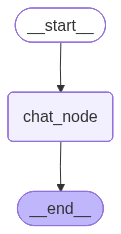

In [16]:
builder = StateGraph(MessagesState)

builder.add_node('chat_node', chat_node)

builder.add_edge(START, 'chat_node')
builder.add_edge('chat_node', END)
checkpointer = InMemorySaver()

workflow = builder.compile(checkpointer=checkpointer)

workflow

In [18]:
config = {'configurable': {'thread_id': '1'}}
workflow.invoke({'messages': [HumanMessage("Hi My name is Atanu")]}, config=config)

Token count 9
Hi My name is Atanu


{'messages': [HumanMessage(content='Hi My name is Atanu', additional_kwargs={}, response_metadata={}, id='11e86af7-715a-4cfb-9b61-358e9f076120'),
  HumanMessage(content='Hello Atanu! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={}, id='cddf0d86-dcec-4dc9-97a8-64f017a4439c')]}

In [19]:
workflow.invoke({'messages': [HumanMessage("Can you explain Short term memory")]}, config=config)

Token count 40
Hi My name is Atanu
Hello Atanu! Nice to meet you. How can I help you today?
Can you explain Short term memory


{'messages': [HumanMessage(content='Hi My name is Atanu', additional_kwargs={}, response_metadata={}, id='11e86af7-715a-4cfb-9b61-358e9f076120'),
  HumanMessage(content='Hello Atanu! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={}, id='cddf0d86-dcec-4dc9-97a8-64f017a4439c'),
  HumanMessage(content='Can you explain Short term memory', additional_kwargs={}, response_metadata={}, id='a102f6b2-77ba-4bb0-8057-18443204e27b'),
  HumanMessage(content='Sure!\u202fShort‑term memory (sometimes called **working memory**) is the brain’s temporary “scratch‑pad” that holds a small amount of information for a brief period—typically on the order of seconds to a few minutes. It’s what lets you remember a phone number long enough to dial it, keep track of the words in a sentence while you’re reading, or follow a set of instructions step‑by‑step.\n\nBelow is a concise overview of the key features, underlying mechanisms, and everyday examples of short‑term memory.\n

In [20]:
workflow.invoke({'messages': [HumanMessage("Can you explain Long term memory")]}, config=config)

Token count 12
Can you explain Long term memory


{'messages': [HumanMessage(content='Hi My name is Atanu', additional_kwargs={}, response_metadata={}, id='11e86af7-715a-4cfb-9b61-358e9f076120'),
  HumanMessage(content='Hello Atanu! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={}, id='cddf0d86-dcec-4dc9-97a8-64f017a4439c'),
  HumanMessage(content='Can you explain Short term memory', additional_kwargs={}, response_metadata={}, id='a102f6b2-77ba-4bb0-8057-18443204e27b'),
  HumanMessage(content='Sure!\u202fShort‑term memory (sometimes called **working memory**) is the brain’s temporary “scratch‑pad” that holds a small amount of information for a brief period—typically on the order of seconds to a few minutes. It’s what lets you remember a phone number long enough to dial it, keep track of the words in a sentence while you’re reading, or follow a set of instructions step‑by‑step.\n\nBelow is a concise overview of the key features, underlying mechanisms, and everyday examples of short‑term memory.\n

In [21]:
workflow.invoke({'messages': [HumanMessage("What is my name ?")]}, config=config)

Token count 9
What is my name ?


{'messages': [HumanMessage(content='Hi My name is Atanu', additional_kwargs={}, response_metadata={}, id='11e86af7-715a-4cfb-9b61-358e9f076120'),
  HumanMessage(content='Hello Atanu! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={}, id='cddf0d86-dcec-4dc9-97a8-64f017a4439c'),
  HumanMessage(content='Can you explain Short term memory', additional_kwargs={}, response_metadata={}, id='a102f6b2-77ba-4bb0-8057-18443204e27b'),
  HumanMessage(content='Sure!\u202fShort‑term memory (sometimes called **working memory**) is the brain’s temporary “scratch‑pad” that holds a small amount of information for a brief period—typically on the order of seconds to a few minutes. It’s what lets you remember a phone number long enough to dial it, keep track of the words in a sentence while you’re reading, or follow a set of instructions step‑by‑step.\n\nBelow is a concise overview of the key features, underlying mechanisms, and everyday examples of short‑term memory.\n